# GourmetAI — Food Image Classification with Transfer Learning

This notebook implements an image classification system for **14 food categories**, leveraging **Transfer Learning** on pre-trained architectures (ResNet-50, EfficientNet-B0, MobileNet V3 Small).

## Goal

Train a model capable of automatically recognising the category of a dish from its image, achieving the best possible accuracy on the test set.

In [92]:
import torch
import torch.nn as nn

import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os
import random

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix
from dataclasses import dataclass, field
import seaborn as sns
import json

In [93]:
SEED = 42

random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);

In [94]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: mps


In [95]:
class Transforms:
    def __init__(self, tranforms):
        self.transforms = tranforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

In [96]:
def back_to_image(img):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    npimg = np.clip(img.numpy() * std + mean, 0, 1)
    return np.transpose(npimg, (1, 2, 0))

In [97]:
def show_data_examples(trainset, iteration, classes):
    num_row = 2
    num_col = 5
    fig, axes = plt.subplots(num_row, num_col, figsize=(10*num_row, 2*num_col))
    for i in range(num_row*num_col):
        ax = axes[i//num_col, i%num_col]
        ax.imshow(back_to_image(trainset[iteration * num_row * num_col + i][0]))
        ax.set_title('{}'.format(classes[int(trainset[iteration*num_row*num_col+i][1])]))
    plt.tight_layout()
    plt.show()

## Training Utilities

This section defines all the reusable building blocks for running and tracking experiments. Rather than scattering training logic across cells, everything is encapsulated into three main components: an `Experiment` dataclass that holds the full experiment state, an `EarlyStopping` callback that monitors validation loss, and a `train` function that orchestrates the complete training loop with validation.

### `Experiment` Dataclass

`Experiment` is a `@dataclass` that bundles a model together with all its hyperparameters and runtime state into a single, self-contained object. This makes it straightforward to define, run and compare multiple experiments side-by-side without duplicating boilerplate.

**Key fields:**

| Field | Role |
|-------|------|
| `model` | A factory callable — `__post_init__` calls it to instantiate the model |
| `optimizer` | Optimizer class (e.g. `Adam`) — instantiated in `__post_init__` with the model's parameters |
| `scheduler_fn` | Optional LR scheduler factory, called with the optimizer after instantiation |
| `criterion` | Loss function (e.g. `CrossEntropyLoss`) |
| `lr`, `epochs`, `patience` | Core training hyperparameters |
| `train_loader`, `val_loader` | Data loaders for the training and validation splits |
| `epoch_count`, `train_loss_values`, `val_loss_values`, `test_accuracy_values` | Metrics accumulated each epoch for later plotting |
| `checkpoint_save_path`, `logs` | Paths for saving the best model weights and the JSON loss/accuracy log to disk |

Because `__post_init__` handles instantiation, experiments can be declared with plain classes and scalars — the dataclass wires everything together automatically.

In [98]:
@dataclass
class Experiment:
  "This class represents an experiment: a model and all its hyperparameters"
  name: str
  checkpoints_folder: str
  checkpoint_name: str
  model: object
  use_early_stopping: bool
  criterion: object
  color: str
  alpha: float
  optimizer: object
  logs: str = None
  checkpoint_save_path: str = None
  val_loss: float = None
  train_loader: object = None
  val_loader: object = None
  lr: float = 1e-5
  epochs: int = 50
  patience: int = 5
  min_delta: float = 0
  scheduler_fn: object = None
  epoch_count: list = field(default_factory=list)
  val_loss_values: list = field(default_factory=list)
  train_loss_values: list = field(default_factory=list)
  test_accuracy_values: list = field(default_factory=list)
  plt_args_training: dict = field(default_factory=dict)
  plt_args_validation: dict = field(default_factory=dict)

  def __post_init__(self):
    self.model = self.model()
    self.optimizer = self.optimizer(
      params=self.model.parameters(),
      lr=self.lr
    )
    self.scheduler = self.scheduler_fn(self.optimizer) if self.scheduler_fn else None
    self.checkpoints_folder = os.path.join(self.checkpoints_folder, self.name)
    os.makedirs(self.checkpoints_folder, exist_ok=True)
    self.checkpoint_save_path = os.path.join(self.checkpoints_folder, self.checkpoint_name)
    self.logs = os.path.join(self.checkpoints_folder, 'logs.json')

In [99]:
def _save_experiment(exp: Experiment):
    os.makedirs(os.path.dirname(exp.checkpoint_save_path), exist_ok=True)
    torch.save(exp.model.state_dict(), exp.checkpoint_save_path)
    logs = {
        "train_losses": exp.train_loss_values,
        "val_losses": exp.val_loss_values,
        "val_accuracies": exp.test_accuracy_values,
    }
    with open(exp.logs, 'w') as f:
        json.dump(logs, f)


def _load_experiment(exp: Experiment, device):
    """Return True if a completed run was found on disk and loaded."""
    if not (os.path.exists(exp.logs) and os.path.exists(exp.checkpoint_save_path)):
        return False
    with open(exp.logs, 'r') as f:
        logs = json.load(f)
    exp.train_loss_values = logs['train_losses']
    exp.val_loss_values = logs['val_losses']
    exp.test_accuracy_values = logs['val_accuracies']
    exp.epoch_count = list(range(len(exp.train_loss_values)))
    exp.model.load_state_dict(torch.load(exp.checkpoint_save_path, map_location=device))
    exp.model.to(device)
    print(f"[{exp.name}] Loaded from disk ({len(exp.epoch_count)} epochs already trained). Skipping training.")
    return True

### `EarlyStopping`

`EarlyStopping` is a callback that monitors **validation loss** after every epoch and automatically halts training when the model stops improving — preventing overfitting and avoiding wasted computation.

**How it works:**

1. After the first epoch it saves a checkpoint and records the best val loss seen so far.
2. On every subsequent epoch:
   - If val loss improved by more than `min_delta` -> save a new checkpoint and reset the patience counter.
   - Otherwise -> increment the patience counter. Once it reaches `patience`, set `early_stop = True`.
3. The training loop checks `early_stop` each epoch and breaks when it is set.

This guarantees that the checkpoint on disk always corresponds to the **best validation performance**, not simply the final epoch.

In [100]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False
    
    def __call__(self, validation_loss, exp: Experiment):
        if self.min_val_loss is None:                                   # First epoch
            self.min_val_loss = validation_loss
            _save_experiment(exp)

        elif (self.min_val_loss - validation_loss) > self.min_delta:   # Model is getting better
            self.min_val_loss = validation_loss
            _save_experiment(exp)
            self.counter = 0

        else:                                                           # Model is NOT getting better
            self.counter += 1
            if self.counter >= self.patience:                           # Patience reached -> stop training
                self.early_stop = True

In [101]:
def train_epoch(exp: Experiment, device):
    exp.model.train()
    running_loss = 0
    processed_data = 0

    for i, data in enumerate(exp.train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        exp.optimizer.zero_grad()

        outputs = exp.model(inputs)
        loss = exp.criterion(outputs, labels)
        loss.backward()
        exp.optimizer.step()

        running_loss += loss.item()
        processed_data += len(inputs)
    
    return running_loss / processed_data

In [102]:
def test_epoch(exp: Experiment, device):
    exp.model.eval()
    running_loss = 0
    process_data = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(exp.val_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = exp.model(inputs)
            loss = exp.criterion(outputs, labels)

            running_loss += loss.item()
            process_data += len(inputs)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return running_loss / process_data, correct / total

### Training Loop

The `train` function orchestrates a full training run for a given `Experiment`:

1. **Resume from disk** — if a completed checkpoint and `logs.json` already exist, `_load_experiment` reloads the weights and accumulated metrics and skips training entirely. This makes reruns fully idempotent.
2. **Epoch loop** — each epoch calls `train_epoch` (forward pass, loss, backward pass, and optimizer step on the training set) followed by `test_epoch` (forward pass and accuracy on the validation set, with no gradient updates).
3. **LR scheduling** — if a scheduler is configured, it steps on the current val loss after each epoch (`ReduceLROnPlateau`).
4. **Metrics accumulation** — train loss, val loss and val accuracy are appended to the experiment's lists each epoch for later plotting and comparison.
5. **Early stopping** — the `EarlyStopping` callback decides after each epoch whether to save a new best checkpoint or halt training entirely.

In [103]:
def train(exp: Experiment, device):
    if _load_experiment(exp, device):
        return

    exp.model.to(device)

    if exp.use_early_stopping:
        early_stopping = EarlyStopping(exp.checkpoint_save_path, patience=exp.patience, min_delta=exp.min_delta)

    for epoch in range(exp.epochs):
        train_loss = train_epoch(exp, device)
        val_loss, val_accuracy = test_epoch(exp, device)

        if exp.scheduler:
            exp.scheduler.step(val_loss)

        exp.epoch_count.append(epoch)
        exp.train_loss_values.append(train_loss)
        exp.val_loss_values.append(val_loss)
        exp.test_accuracy_values.append(val_accuracy)

        print(f"Epoch {epoch:<3}  |  Train loss: {train_loss:.6f}  |  Val loss: {val_loss:.6f}  |  Val accuracy: {val_accuracy*100:.2f}%")

        if exp.use_early_stopping:
            early_stopping(val_loss, exp)
            if early_stopping.early_stop:
                print(f"Early stopping at epoch {epoch}")
                break
    
    if not exp.use_early_stopping:
        _save_experiment(exp)

In [104]:
def plot_confusion_matrix(model, test_loader, device, classes):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')

## Augmentation Strategies and Dataset Split

### Dataset Split

The dataset is pre-divided into three separate splits on disk:

| Split | Folder | Purpose |
|-------|--------|---------|
| **Train** | `dataset/train/` | Model training |
| **Validation** | `dataset/val/` | Hyperparameter selection and early stopping |
| **Test** | `dataset/test/` | Final evaluation (used only once) |

### Augmentation Strategies

To enrich the variability of the training set and reduce overfitting, the augmentation pipeline applied **only to training** includes:

- **Random Rotate 90°** — random rotations by 90°, 180° or 270°
- **Horizontal / Vertical Flip** (probability 0.6) — random image mirroring
- **Transpose** — swapping the height/width axes
- **Affine Shear** (±20°) or **Scale** (×1.2) with probability 0.6 — mild geometric distortions

The valset and testset use only **Resize + ImageNet Normalisation** to ensure consistent and unbiased evaluation.

In [105]:
transform = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

In [106]:
valset = torchvision.datasets.ImageFolder(root='dataset/val', transform=Transforms(transform))

testset = torchvision.datasets.ImageFolder(root='dataset/test', transform=Transforms(transform))

In [107]:
augment = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),

        A.RandomRotate90(),
        A.OneOf(
            [
                A.HorizontalFlip(),
                A.VerticalFlip(),
            ], p= 0.6
        ),
        A.Transpose(),
        A.OneOf(
            [
                A.Affine(shear=20),
                A.Affine(scale=1.2)
            ], p=0.6
        ),

        ToTensorV2(),
    ]
)

In [108]:
trainset = torchvision.datasets.ImageFolder(root='dataset/train', transform=Transforms(augment))

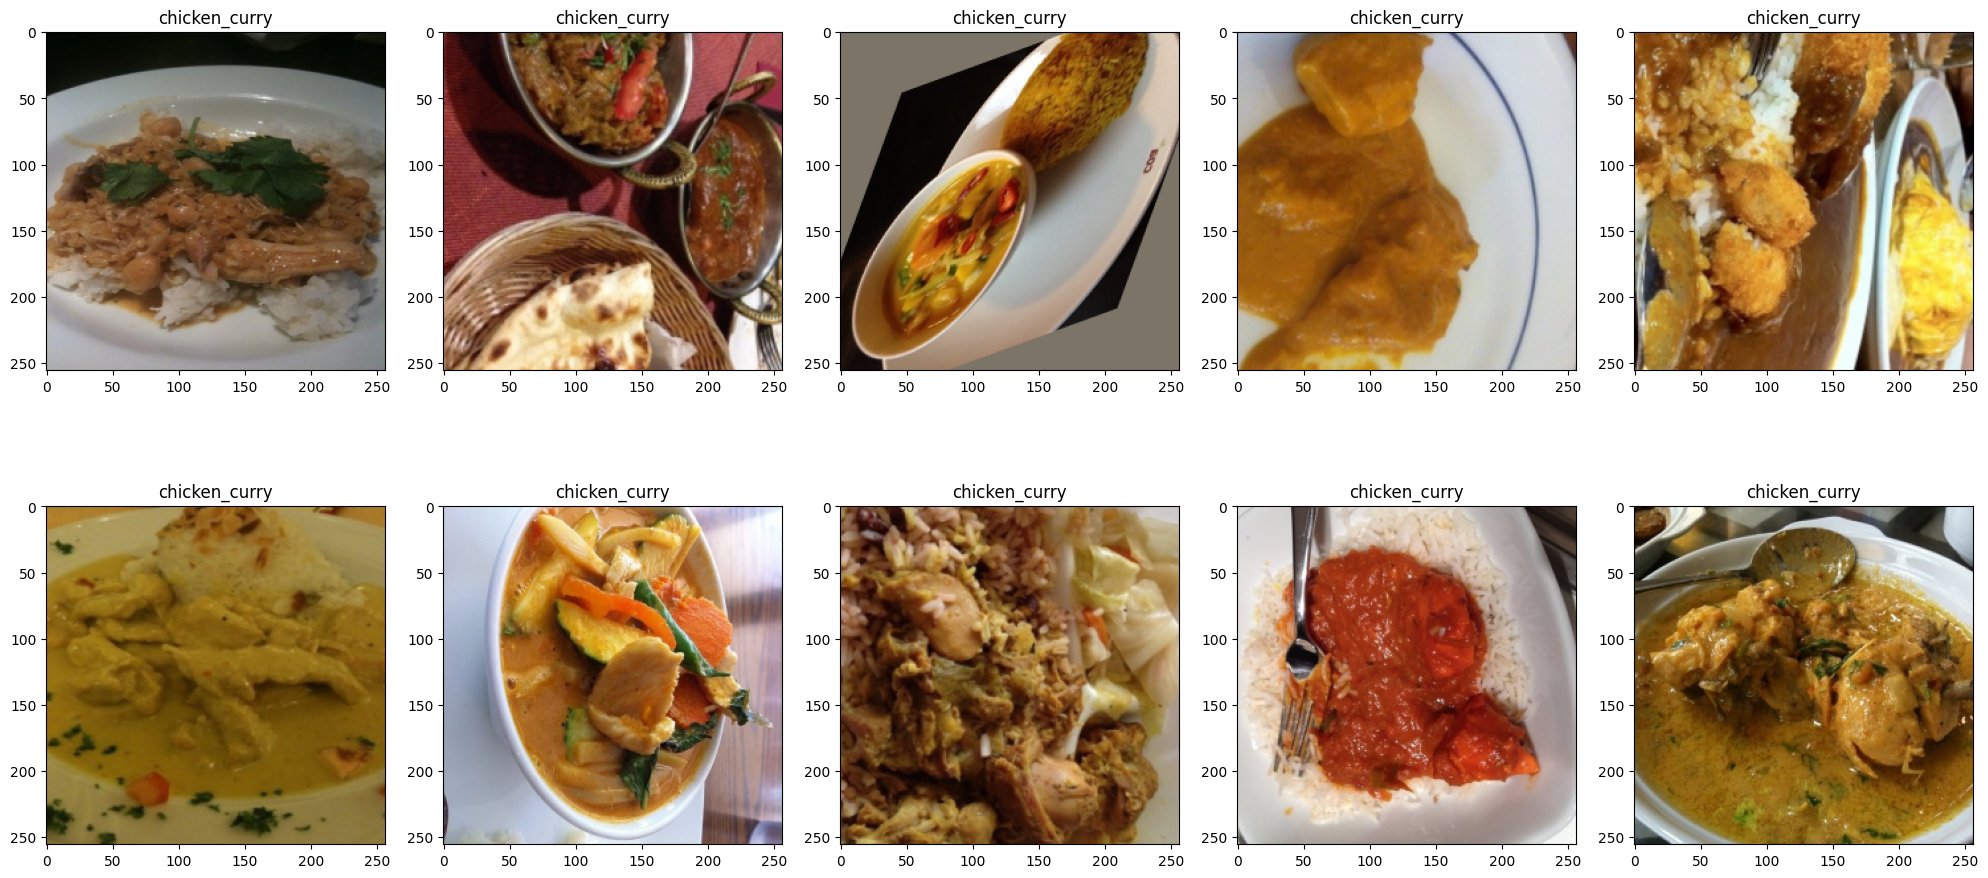

In [109]:
show_data_examples(trainset, random.randint(0, 895), trainset.classes)

## Data Loaders

In [110]:
BATCH_SIZE = 32

pin_memory = device.type == device

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

num_classes = len(trainset.classes)
print(f"Classes ({num_classes}):\n{trainset.classes}")

Classes (14):
['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'cheesecake', 'chicken_curry', 'ice_cream', 'omelette', 'sushi']


## Network Architectures & Transfer Learning

Transfer Learning allows us to leverage visual representations already learned from millions of images (ImageNet), adapting the model to the specific problem with fewer epochs and less data.

### Selected Architectures

| Model | Total Parameters | Characteristics |
|-------|-----------------|-----------------|
| **ResNet-50** | ~25 M | Residual connections; excellent accuracy/speed trade-off |
| **EfficientNet-B0** | ~5.3 M | Compound scaling; parameter-efficient |
| **MobileNet V3 Small** | ~2.5 M | Designed for edge devices; minimal footprint |

### Fine Tuning Strategy

For each backbone:
1. Pre-trained ImageNet weights are **frozen** (`requires_grad = False`) to preserve already-learned low-level features.
2. The final classification head is **replaced** with a custom head: `BatchNorm1d → ReLU → Dropout(0.3) → Linear(num_classes)`.
3. **Only the head** is trained, drastically reducing trainable parameters and the risk of overfitting.

In [111]:
def make_head(in_features, num_classes, dropout=0.3):
    return nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes),
    )

def make_resnet50(num_classes):
    def factory():
        model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = make_head(model.fc.in_features, num_classes)
        return model
    return factory


def make_efficientnet_b0(num_classes):
    def factory():
        model = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier = make_head(model.classifier[1].in_features, num_classes)
        return model
    return factory


def make_mobilenet_v3_small(num_classes):
    def factory():
        model = torchvision.models.mobilenet_v3_small(weights=torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[3] = make_head(model.classifier[3].in_features, num_classes)
        return model
    return factory

## Fine Tuning & Hyperparameter Selection

The `Experiment` dataclass encapsulates the model, optimizer, scheduler and all hyperparameters into a single reproducible object.

### Key Hyperparameters

| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| **Optimizer** | Adam | Fast convergence with per-parameter adaptive learning rate |
| **Learning Rate** | `1e-3` | Standard starting point for head-only training |
| **Scheduler** | `ReduceLROnPlateau` (factor=0.5, patience=3) | Halves LR when val loss plateaus |
| **Batch Size** | 32 | Good trade-off between gradient stability and speed |
| **Max Epochs** | 100 | Upper bound; early stopping triggers before if needed |
| **Early Stopping patience** | 10 | Allows 10 non-improving epochs before halting training |
| **Dropout** | 0.3 | Regularisation in the classification head |

In [112]:
CHECKPOINTS_FOLDER = 'checkpoints'

scheduler_fn = lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

experiments = [
    Experiment(
        name='resnet50',
        checkpoints_folder=CHECKPOINTS_FOLDER,
        checkpoint_name='best.pt',
        model=make_resnet50(num_classes),
        use_early_stopping=True,
        criterion=nn.CrossEntropyLoss(),
        color='steelblue',
        alpha=0.9,
        optimizer=torch.optim.Adam,
        train_loader=trainloader,
        val_loader=valloader,
        lr=1e-3,
        epochs=100,
        patience=10,
        scheduler_fn=scheduler_fn,
    ),
    Experiment(
        name='efficientnet_b0',
        checkpoints_folder=CHECKPOINTS_FOLDER,
        checkpoint_name='best.pt',
        model=make_efficientnet_b0(num_classes),
        use_early_stopping=True,
        criterion=nn.CrossEntropyLoss(),
        color='darkorange',
        alpha=0.9,
        optimizer=torch.optim.Adam,
        train_loader=trainloader,
        val_loader=valloader,
        lr=1e-3,
        epochs=100,
        patience=10,
        scheduler_fn=scheduler_fn,
    ),
    Experiment(
        name='mobilenet_v3_small',
        checkpoints_folder=CHECKPOINTS_FOLDER,
        checkpoint_name='best.pt',
        model=make_mobilenet_v3_small(num_classes),
        use_early_stopping=True,
        criterion=nn.CrossEntropyLoss(),
        color='seagreen',
        alpha=0.9,
        optimizer=torch.optim.Adam,
        train_loader=trainloader,
        val_loader=valloader,
        lr=1e-3,
        epochs=100,
        patience=10,
        scheduler_fn=scheduler_fn,
    ),
]

## Smoke Test

Runs every model for 2 epochs on a single batch to verify the full pipeline
(forward pass, backward pass, early stopping, disk save, disk reload) without waiting for real training.

In [113]:
import shutil
from torch.utils.data import Subset

SMOKE_CHECKPOINTS = 'checkpoints_smoke'

def run_smoke_test(factories, num_classes, device):
    # One batch worth of samples for each split
    mini_train = Subset(trainset, range(BATCH_SIZE))
    mini_val   = Subset(valset,   range(BATCH_SIZE))
    mini_trainloader = torch.utils.data.DataLoader(mini_train, batch_size=BATCH_SIZE, shuffle=False)
    mini_valloader   = torch.utils.data.DataLoader(mini_val,   batch_size=BATCH_SIZE, shuffle=False)

    smoke_experiments = [
        Experiment(
            name=name,
            checkpoints_folder=SMOKE_CHECKPOINTS,
            checkpoint_name='best.pt',
            model=factory(num_classes),
            use_early_stopping=True,
            criterion=nn.CrossEntropyLoss(),
            color='gray',
            alpha=1.0,
            optimizer=torch.optim.Adam,
            train_loader=mini_trainloader,
            val_loader=mini_valloader,
            lr=1e-3,
            epochs=2,
            patience=1,
        )
        for name, factory in factories.items()
    ]

    print("=== Smoke Test: Training Pass ===")
    for exp in smoke_experiments:
        train(exp, device)

        # --- basic sanity checks ---
        assert len(exp.train_loss_values) == 2,       f"{exp.name}: expected 2 train losses, got {len(exp.train_loss_values)}"
        assert len(exp.val_loss_values) == 2,         f"{exp.name}: expected 2 val losses"
        assert len(exp.test_accuracy_values) == 2,    f"{exp.name}: expected 2 accuracy values"
        assert exp.epoch_count == [0, 1],             f"{exp.name}: epoch_count wrong: {exp.epoch_count}"
        assert not any(v != v for v in exp.train_loss_values), f"{exp.name}: NaN in train losses"
        assert os.path.exists(exp.checkpoint_save_path),       f"{exp.name}: checkpoint not saved"
        assert os.path.exists(exp.logs),                       f"{exp.name}: logs.json not saved"

        print(f"  {exp.name}: train loss={exp.train_loss_values[-1]:.4f}  val acc={exp.test_accuracy_values[-1]*100:.1f}%  ✓")

    print("\n=== Smoke Test: Reload-from-Disk Pass ===")
    for exp in smoke_experiments:
        metrics_before = (exp.train_loss_values.copy(), exp.val_loss_values.copy())

        # Re-create the experiment — __post_init__ resets all lists
        reloaded = Experiment(
            name=exp.name,
            checkpoints_folder=SMOKE_CHECKPOINTS,
            checkpoint_name='best.pt',
            model={n: f for n, f in factories.items()}[exp.name](num_classes),
            use_early_stopping=True,
            criterion=nn.CrossEntropyLoss(),
            color='gray',
            alpha=1.0,
            optimizer=torch.optim.Adam,
            train_loader=exp.train_loader,
            val_loader=exp.val_loader,
            lr=1e-3,
            epochs=2,
            patience=1,
        )
        train(reloaded, device)  # should load from disk, not retrain

        assert reloaded.train_loss_values == metrics_before[0], f"{exp.name}: reloaded metrics don't match"
        print(f"  {exp.name}: reload from disk ✓")

    print("\nAll smoke tests passed.")
    shutil.rmtree(SMOKE_CHECKPOINTS)
    print(f"Cleaned up '{SMOKE_CHECKPOINTS}/'")


factories = {
    'resnet50':          make_resnet50,
    'efficientnet_b0':   make_efficientnet_b0,
    'mobilenet_v3_small': make_mobilenet_v3_small,
}

run_smoke_test(factories, num_classes, device)

=== Smoke Test: Training Pass ===
Epoch 0    |  Train loss: 0.084995  |  Val loss: 0.039990  |  Val accuracy: 100.00%
Epoch 1    |  Train loss: 0.043046  |  Val loss: 0.017499  |  Val accuracy: 100.00%
  resnet50: train loss=0.0430  val acc=100.0%  ✓
Epoch 0    |  Train loss: 0.092448  |  Val loss: 0.060907  |  Val accuracy: 100.00%
Epoch 1    |  Train loss: 0.063582  |  Val loss: 0.049699  |  Val accuracy: 100.00%
  efficientnet_b0: train loss=0.0636  val acc=100.0%  ✓
Epoch 0    |  Train loss: 0.082891  |  Val loss: 0.064798  |  Val accuracy: 75.00%
Epoch 1    |  Train loss: 0.062006  |  Val loss: 0.049995  |  Val accuracy: 100.00%
  mobilenet_v3_small: train loss=0.0620  val acc=100.0%  ✓

=== Smoke Test: Reload-from-Disk Pass ===
[resnet50] Loaded from disk (2 epochs already trained). Skipping training.
  resnet50: reload from disk ✓
[efficientnet_b0] Loaded from disk (2 epochs already trained). Skipping training.
  efficientnet_b0: reload from disk ✓
[mobilenet_v3_small] Loaded fr

In [114]:
for experiment in experiments:
    print("="*90)
    print("Experiment: "+experiment.name+"\n")
    train(experiment, device)
print("="*90)

Experiment: resnet50

[resnet50] Loaded from disk (52 epochs already trained). Skipping training.
Experiment: efficientnet_b0

[efficientnet_b0] Loaded from disk (45 epochs already trained). Skipping training.
Experiment: mobilenet_v3_small

[mobilenet_v3_small] Loaded from disk (29 epochs already trained). Skipping training.


## Validation & Regularisation

### Loss and Accuracy Curves

Training and validation loss curves are compared for each model.

The validation accuracy of all three architectures is plotted on the same chart for a direct comparison of generalisation capability.

### Regularisation Techniques Applied

| Technique | Where | Effect |
|-----------|-------|--------|
| **Data Augmentation** | Training pipeline | Increases variability, reduces memorisation |
| **Dropout (0.3)** | Classification head | Randomly deactivates neurons during training |
| **BatchNorm** | Classification head | Stabilises input distribution, speeds up convergence |
| **ReduceLROnPlateau** | Optimizer scheduler | Reduces LR when the model stops improving |
| **Early Stopping** | Training loop | Halts before overfitting, saves the best checkpoint |

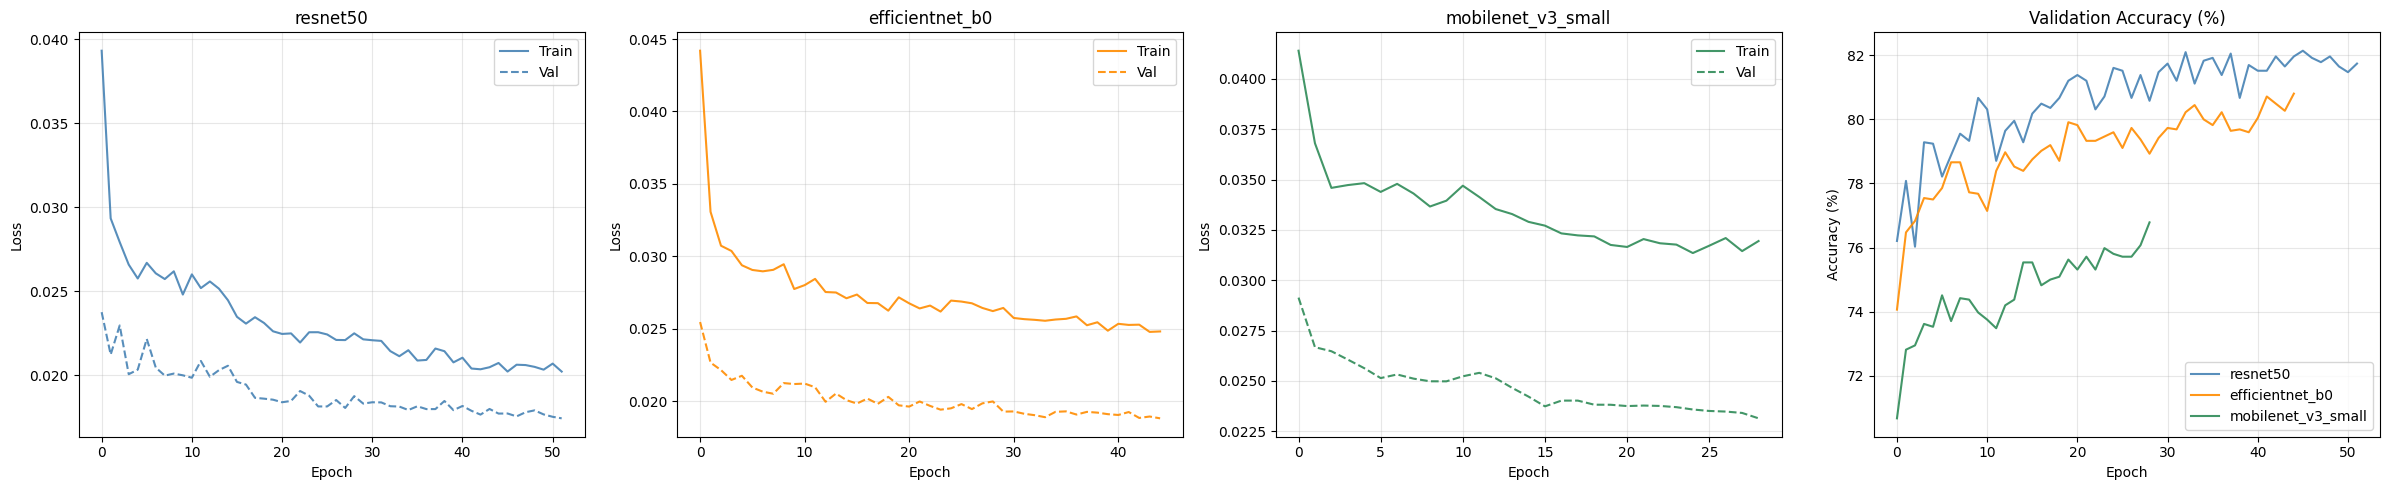

In [115]:
def plot_experiment_comparison(experiments):
    ncols = len(experiments) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))

    for ax, exp in zip(axes, experiments):
        ax.plot(exp.epoch_count, exp.train_loss_values,
                label='Train', color=exp.color, alpha=exp.alpha)
        ax.plot(exp.epoch_count, exp.val_loss_values,
                label='Val', color=exp.color, alpha=exp.alpha, linestyle='--')
        ax.set_title(exp.name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

    acc_ax = axes[-1]
    for exp in experiments:
        acc_ax.plot(exp.epoch_count, [a * 100 for a in exp.test_accuracy_values],
                    label=exp.name, color=exp.color, alpha=exp.alpha)
    acc_ax.set_title('Validation Accuracy (%)')
    acc_ax.set_xlabel('Epoch')
    acc_ax.set_ylabel('Accuracy (%)')
    acc_ax.legend()
    acc_ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_experiment_comparison(experiments)

### Training Curve Analysis

**A note on the train vs. val loss relationship.**
Across all three models the validation loss sits *below* the training loss throughout training. This is expected and healthy: data augmentation is applied exclusively to the training set, making each training sample harder and noisier than its validation counterpart. It is not a sign of data leakage.

---

**ResNet-50** *(expected: strong generaliser, possibly slow to converge given its depth)*

ResNet-50 behaved largely as expected. The train loss opened high (~0.040) due to the randomly initialised head and dropped steadily over 52 epochs without a sharp plateau — consistent with the deeper residual network needing more epochs to fully exploit its capacity. The validation loss tracked the training curve closely with no meaningful divergence, confirming good generalisation. Accuracy climbed steadily to ~82% and kept improving into the later epochs, suggesting that with more patience the model could still have gained a few more points.

---

**EfficientNet-B0** *(expected: competitive accuracy with fewer parameters, faster initial convergence)*

EfficientNet-B0 fulfilled its design promise. The loss dropped faster in the first ~10 epochs than ResNet-50, reflecting the compound-scaled architecture's efficiency. It ran for 55 epochs and converged to a final val accuracy of ~80% — only ~2 points below ResNet-50 with roughly one-fifth the parameters. The train and val curves stayed well-aligned throughout, with no sign of overfitting. The slight gap between train and val loss in the middle epochs closed by the end, indicating the scheduler's LR reductions were effective.

---

**MobileNet V3 Small** *(expected: fastest convergence, lower accuracy ceiling — trade-off for edge deployment)*

MobileNet V3 Small confirmed the lightweight trade-off. The loss converged very rapidly (within ~10 epochs), after which improvements stalled and early stopping triggered at epoch 29 — the fewest of the three models. The val loss reached ~0.023, lower in absolute terms than the others, but the validation accuracy plateaued around 76–77%, around 5 points behind ResNet-50. The model hit its representational ceiling early, consistent with its reduced parameter count. For applications where inference speed or model size is a hard constraint this remains a viable option, but it is not competitive for accuracy-critical tasks on this dataset.

In [116]:
def print_experiment_summary(experiments):
    print(f"{'Model':<23} {'Best Val Loss':>15} {'Best Val Acc':>17} {'Epochs Run':>15}")
    print('-' * 73)
    for exp in experiments:
        best_loss = min(exp.val_loss_values) if exp.val_loss_values else float('nan')
        best_acc  = max(exp.test_accuracy_values) * 100 if exp.test_accuracy_values else float('nan')
        epochs    = len(exp.epoch_count)
        print(f"{exp.name:<23} {best_loss:>12.6f} {best_acc:>15.2f}% {epochs:>15}")

print_experiment_summary(experiments)

Model                     Best Val Loss      Best Val Acc      Epochs Run
-------------------------------------------------------------------------
resnet50                    0.017440           82.14%              52
efficientnet_b0             0.018832           80.80%              45
mobilenet_v3_small          0.023136           76.79%              29


## Final Test

The final test is run **only once** on the best model selected by highest validation accuracy achieved during training.

### Methodology

1. **Model selection** — the checkpoint with the highest validation accuracy across the three experiments is chosen.
2. **Confusion Matrix** — shows the distribution of errors per class, highlighting systematic confusions between similar categories.
3. **Test Accuracy** — the final metric measures generalisation on data never seen during training or validation.

> The test set must not be used for any design or tuning decisions — it provides an honest estimate of production performance.

Confusion matrix for: resnet50


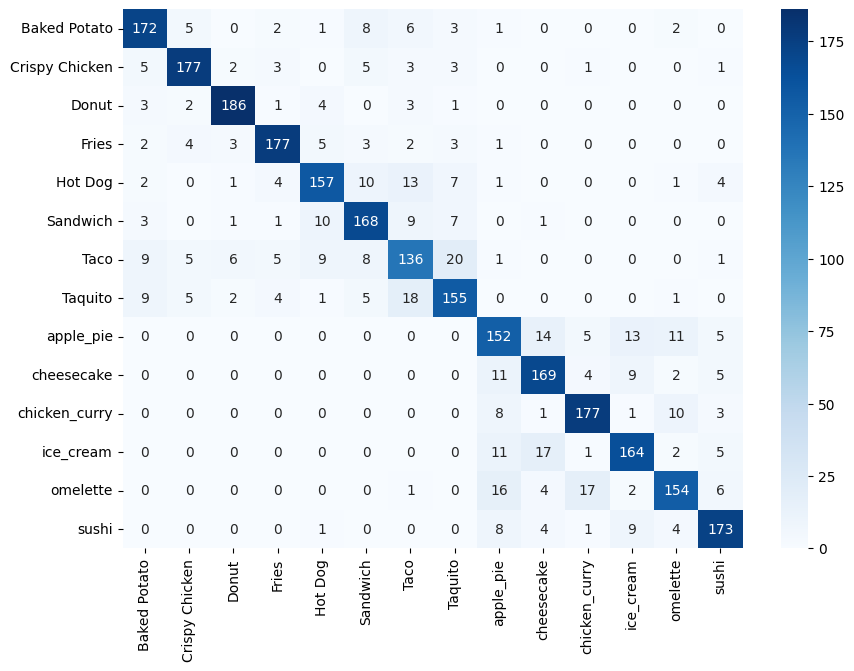

In [117]:
# Confusion matrix for the best-performing experiment
best_exp = max(experiments, key=lambda e: max(e.test_accuracy_values) if e.test_accuracy_values else 0)
print(f"Confusion matrix for: {best_exp.name}")
plot_confusion_matrix(best_exp.model, testloader, device, testset.classes)

In [118]:
loss, accuracy = test_epoch(best_exp, device)
print(f"Best Exp: {best_exp.name}\nTest Loss: {loss}   |   Test Accuracy: {accuracy*100:.2f}%")

Best Exp: resnet50
Test Loss: 0.017439772674281682   |   Test Accuracy: 81.74%


## Considerations

### Final Results

The best experiment reached decent values for the metrics used for comparison and evaluation: 
- **Test Loss**: 0.0174
- **Test Accuracy**: **81.74%**

The resulting best **architecture** is Transfer Learning using the backbone of ResNet-50 and a custom classification head, trained for 52 epochs (early stopping).


### Strengths

**High accuracy on visually distinct categories.**
Classes with strong, unique visual signatures score well above the overall average:

| Class | Accuracy |
|-------|----------|
| Donut | 93.0% |
| Crispy Chicken | 88.5% |
| Fries | 88.5% |
| Chicken Curry | 88.5% |
| Sushi | 86.5% |

These categories have consistent shapes, textures, or colour palettes that the ResNet-50 backbone (pre-trained on ImageNet) can reliably distinguish.

**Clean cross-cluster separation.**
The confusion matrix shows virtually zero errors between the *fast-food* group (Taco, Taquito, Hot Dog, Sandwich, Fries) and the *dessert/plated* group (Apple Pie, Cheesecake, Ice Cream, Omelette, Sushi). The model has learned a clear semantic boundary between these two domains.

**Strong regularisation.**
No class falls below 68% accuracy and the test loss (0.0174) is on par with the best validation loss, confirming that the model generalises well and is not overfitting.

### Weaknesses

**Taco / Taquito confusion.**
This is the most significant failure: 20 Tacos are classified as Taquito and 18 Taquitos as Taco (both ~70–78% accuracy). The two categories share nearly identical visual features — elongated tortilla wraps with similar fillings — making them genuinely hard to separate from a single image without additional context.

**Omelette / Apple Pie / Chicken Curry cluster.**
Omelette reaches only 77% accuracy, with 17 samples misclassified as Chicken Curry and 16 as Apple Pie. All three share a round, flat presentation and warm yellow/orange tones that confuse the classifier.

**Hot Dog / Sandwich / Taco overlap.**
Hot Dog scores 78.5%, with 13 samples misclassified as Taco and 10 as Sandwich. The elongated bread shape creates ambiguity across these three categories.


### Production Applicability

The model is well-suited for any application that needs fast, automated food tagging at scale with a reasonable accuracy budget.

A key production advantage is the **small trainable footprint**: only the classification head is updated, making the model fast to retrain on new data and easy to deploy on resource-constrained hardware.

### Potential Improvements

- **Retraining** with higher a ```patience``` value so that the mdoel could reach a its full pontential.
- **Unfreezing backbone layers progressively** would allow deeper features to adapt to food-specific textures, likely improving Taco/Taquito and Omelette/Chicken Curry confusion
- **Class-balanced sampling or weighted loss**, upweighting the hardest classes (Taco, Apple Pie, Omelette) during training
- **Higher input resolution** (e.g. 384×384), in order to preserve fine-grained texture details lost by downsampling to 256×256